# Fusion Forge Training Series
# Transfer Learning & Fine-Tuning on **Thermal Camera** Images (Keras 3)

## What this lab is about

In this lab you will build an image classifier for **thermal (infrared) camera**
images **without training a network from scratch**. Instead, you reuse a large model
(**Xception**) that was already trained on millions of ordinary photos (ImageNet) and
*adapt* it to your thermal data. This technique is called **transfer learning**, and the
optional polishing step at the end is called **fine-tuning**.

By the end you will have trained a model that tells apart thermal frames of **dogs** and
**people**, evaluated it honestly, and visualised what it learned.

## Why transfer learning (the core idea)

A deep vision model learns features in layers:

- **Early layers** learn *generic* patterns — edges, blobs, gradients, textures.
- **Later layers** learn *task-specific* patterns — "this looks like a dog's shape".

The generic early features are useful for **almost any** image task, even one the model
has never seen. Thermal images are a great example: ImageNet contains **zero** thermal
photos, yet the reused features still work well. Transfer learning is the right tool when
you have a **small and/or unusual dataset**, because training from scratch would overfit.

## The two-phase workflow (schema)

```mermaid
flowchart TD
    A["Pre-trained Xception<br/>(trained on ImageNet)"] --> B["Remove original classifier<br/>keep the convolutional 'feature extractor'"]
    B --> C["Add a new head<br/>GlobalAveragePooling → Dropout → Dense(2)"]

    subgraph P1["PHASE 1 — Feature extraction (fast)"]
        D["FREEZE the whole base<br/>(weights not updated)"] --> E["Train ONLY the new head<br/>optimizer = Adam, lr = 1e-3"]
    end

    subgraph P2["PHASE 2 — Fine-tuning (gentle)"]
        F["UNFREEZE only the TOP layers<br/>keep BatchNorm frozen"] --> G["Re-train with a TINY lr = 1e-5<br/>(100× smaller)"]
    end

    C --> P1 --> P2 --> H["Evaluate on the test set<br/>accuracy, confusion matrix"]
```

**Why two phases?**
1. **Freeze first.** The new head starts with random weights. If we trained everything at
   once, the large early gradients from that random head would *destroy* the valuable
   pre-trained features. Freezing protects them while the head learns.
2. **Fine-tune second, gently.** Once the head is good, we unfreeze the top of the base and
   nudge it with a **very small** learning rate so the pre-trained features adapt to thermal
   imagery without being wiped out. We keep **BatchNorm** layers frozen and only unfreeze the
   **top** layers — this saves GPU memory and reduces overfitting on a small dataset.

## Dataset

`Francesco/thermal-dogs-and-people-x6ejw` (Hugging Face) — real thermal footage frames with
labelled objects. It ships as an *object-detection* dataset (`dog`, `person`), so we convert
it into a simple **image-classification** task: each frame is labelled with its **dominant
subject** (the object covering the largest area). Frames with no objects are dropped.

> A clean thermal *vehicle* classification set isn't publicly downloadable without sign-up,
> so we use this openly available thermal *people vs. dogs* set. The workflow is **identical**
> for any thermal classes you later collect (just point it at your own images).

## Learning objectives

By the end of this notebook you will be able to:
1. Load and decode an image dataset and build an efficient `tf.data` input pipeline.
2. Attach a new classification head onto a **frozen** pre-trained backbone.
3. Run the **two-phase** workflow (feature extraction → fine-tuning) and explain *why*.
4. Apply memory-saving tricks (small batches, partial unfreezing) on a limited GPU.
5. Read learning curves and a confusion matrix to judge model quality.

## Notebook roadmap
| Step | What happens |
|------|--------------|
| 1 | Download the thermal dataset (Parquet from Hugging Face) |
| 2 | Decode images and build one class label per frame |
| 3 | Split into train / validation / test |
| 4 | Build the augmentation + input pipeline |
| 5 | Build the model (frozen Xception + new head) |
| 6 | **Phase 1** — train the head |
| 7 | **Phase 2** — fine-tune the top layers |
| 8–10 | Evaluate, plot learning curves, and test on real images |

> **Tip for running:** start from a fresh kernel and run top-to-bottom. The first code cell
> sets GPU memory options that must be applied *before* TensorFlow initialises.

In [1]:
import os

# Let TensorFlow grow GPU memory on demand instead of grabbing a fixed slice up
# front. Important on unified-memory devices (e.g. GB10) to avoid early OOM.
os.environ.setdefault("TF_FORCE_GPU_ALLOW_GROWTH", "true")
os.environ.setdefault("XLA_FLAGS", "--xla_gpu_strict_conv_algorithm_picker=false")

import io
import json
import urllib.request

import numpy as np
import pyarrow.parquet as pq
from PIL import Image

import keras
from keras import layers
import tensorflow as tf  # used only for the tf.data input pipeline

for gpu in tf.config.list_physical_devices("GPU"):
    try:
        tf.config.experimental.set_memory_growth(gpu, True)
    except RuntimeError as e:
        print("Could not set memory growth:", e)

print("Keras version:", keras.__version__)
print("Backend:", keras.backend.backend())
print("GPUs:", tf.config.list_physical_devices("GPU"))

2026-07-08 19:16:53.230690: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:485] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-07-08 19:16:53.238952: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:8473] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-07-08 19:16:53.242480: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1471] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-07-08 19:16:53.999566: W tensorflow/compiler/tf2tensorrt/utils/py_utils.cc:38] TF-TRT Warning: Could not find TensorRT: INTERNAL: Cannot dlopen all TensorRT libraries: FAILED_PRECONDITION: Could not load dynamic library 'libnvinfer.so.10.8.0'; dlerror: libnvinfer.so.10.8.0: cannot open shared object file: No such file or directory


Keras version: 3.15.0
Backend: tensorflow
GPUs: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


I0000 00:00:1783563415.470852   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783563415.506783   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783563415.509858   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783563415.506783   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

## 1. Download the thermal dataset

The dataset is stored as Parquet files on the Hugging Face Hub. We discover the file
names through the Hub API (so this keeps working if the hashes change) and download
the raw bytes — no extra libraries beyond `pyarrow` required.

In [2]:
REPO = "Francesco/thermal-dogs-and-people-x6ejw"
HDRS = {"User-Agent": "curl/8"}


def http_json(url):
    return json.load(urllib.request.urlopen(urllib.request.Request(url, headers=HDRS)))


def http_bytes(url):
    return urllib.request.urlopen(urllib.request.Request(url, headers=HDRS)).read()


# List every parquet file in the repo's data/ folder.
tree = http_json(f"https://huggingface.co/api/datasets/{REPO}/tree/main?recursive=true")
parquet_files = sorted(t["path"] for t in tree if t["path"].endswith(".parquet"))
print("Parquet files found:")
for p in parquet_files:
    print("  ", p)

Parquet files found:
   data/test-00000-of-00001-d8b5e33cc7b3e0f0.parquet
   data/train-00000-of-00001-1610caffe8805fb2.parquet
   data/validation-00000-of-00001-7c75a093271552c9.parquet


## 2. Decode images & build classification labels

Each row holds a JPEG (as bytes) plus a list of detected `objects`. We convert detection
into classification with a simple rule: **the label is the category of the largest-area
object** in the frame. This gives one clean label per image.

The original category list is `["thermal-dogs-n-people", "dog", "person"]` where index 0
is an unused super-category, so our real classes are **`dog`** and **`person`**.

In [3]:
IMG_SIZE = 224
RAW_CATEGORIES = ["thermal-dogs-n-people", "dog", "person"]  # index 0 unused

images, labels = [], []

for fname in parquet_files:
    url = f"https://huggingface.co/datasets/{REPO}/resolve/main/{fname}"
    table = pq.read_table(io.BytesIO(http_bytes(url)))
    for row in table.to_pylist():
        objs = row["objects"]
        areas = objs.get("area", [])
        cats = objs.get("category", [])
        if not cats:
            continue  # skip frames with no labelled subject
        dominant = cats[int(np.argmax(areas))]  # category of the biggest object
        img = Image.open(io.BytesIO(row["image"]["bytes"]))
        img = img.convert("RGB").resize((IMG_SIZE, IMG_SIZE))
        images.append(np.asarray(img, dtype=np.uint8))
        labels.append(dominant)

images = np.stack(images)
labels = np.array(labels, dtype=np.int64)

# Remap the raw category ids (1, 2) to contiguous 0-based class indices.
used_ids = sorted(np.unique(labels).tolist())
id_to_idx = {cat_id: i for i, cat_id in enumerate(used_ids)}
labels = np.array([id_to_idx[v] for v in labels], dtype=np.int64)
class_names = [RAW_CATEGORIES[i] for i in used_ids]
n_classes = len(class_names)

print("images:", images.shape, images.dtype)
print("classes:", class_names)
for i, name in enumerate(class_names):
    print(f"  {name}: {(labels == i).sum()} images")

images: (185, 224, 224, 3) uint8
classes: ['dog', 'person']
  dog: 85 images
  person: 100 images


### Peek at the data

**Always look at your data before training.** Thermal images look very different from
ordinary photos — brighter = hotter. Below is one example per class.

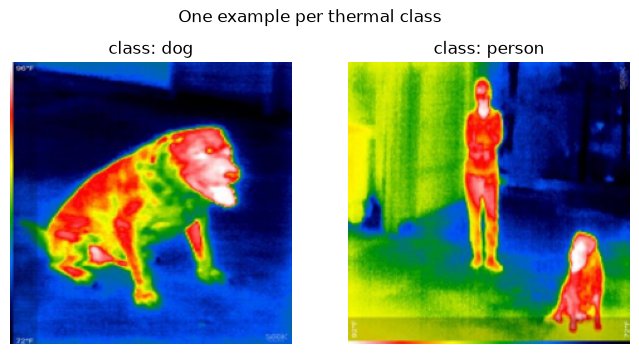

In [11]:
import matplotlib.pyplot as plt

plt.figure(figsize=(4 * n_classes, 4))
for i, name in enumerate(class_names):
    example = images[labels == i][0]
    plt.subplot(1, n_classes, i + 1)
    plt.imshow(example)
    plt.title(f"class: {name}")
    plt.axis("off")
plt.suptitle("One example per thermal class")
plt.show()

## 3. Train / validation / test split

We shuffle once (fixed seed for reproducibility) and split into three disjoint parts:
- **Train (75%)** — the model learns from these.
- **Validation (15%)** — watched during training to detect overfitting.
- **Test (10%)** — used **once** at the end for an honest score.

In [4]:
rng = np.random.default_rng(42)
perm = rng.permutation(len(images))
images, labels = images[perm], labels[perm]

n = len(images)
test_size = int(n * 0.10)
valid_size = int(n * 0.15)
train_size = n - test_size - valid_size

X_train, y_train = images[:train_size], labels[:train_size]
X_valid, y_valid = images[train_size:train_size + valid_size], labels[train_size:train_size + valid_size]
X_test, y_test = images[train_size + valid_size:], labels[train_size + valid_size:]

print(f"train={len(X_train)}, valid={len(X_valid)}, test={len(X_test)}")

train=140, valid=27, test=18


## 4. Data augmentation + input pipeline

With so few images, **augmentation matters a lot** — it invents new, realistic variations
so the model sees more diversity and overfits less. As before, pixel scaling is **not**
done here; it lives inside the model as a `Rescaling` layer.

In [5]:
batch_size = 8  # small batch keeps GPU memory usage low (shared/limited GPU)
AUTOTUNE = tf.data.AUTOTUNE

data_augmentation = keras.Sequential(
    [
        layers.RandomFlip("horizontal"),
        layers.RandomRotation(0.1),
        layers.RandomZoom(0.1),
    ],
    name="data_augmentation",
)


def make_ds(X, y, training=False):
    ds = tf.data.Dataset.from_tensor_slices((X, y))
    if training:
        ds = ds.shuffle(len(X))
    ds = ds.map(lambda img, lbl: (tf.cast(img, tf.float32), lbl), num_parallel_calls=AUTOTUNE)
    ds = ds.batch(batch_size)
    if training:
        ds = ds.map(lambda img, lbl: (data_augmentation(img, training=True), lbl),
                    num_parallel_calls=AUTOTUNE)
    return ds.prefetch(AUTOTUNE)


train_set = make_ds(X_train, y_train, training=True)
valid_set = make_ds(X_valid, y_valid)
test_set = make_ds(X_test, y_test)

I0000 00:00:1783563436.537378   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783563436.540486   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783563436.543086   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS had negative value (-1), but there must be at least one NUMA node, so returning NUMA node zero. See more at https://github.com/torvalds/linux/blob/v6.0/Documentation/ABI/testing/sysfs-bus-pci#L344-L355
I0000 00:00:1783563436.717482   76462 cuda_executor.cc:1015] successful NUMA node read from SysFS ha

## 5. Build the transfer-learning model

Identical blueprint to the flowers notebook:
- `Rescaling` maps `[0, 255]` pixels to `[-1, 1]` (what Xception expects).
- The frozen `base_model` runs with `training=False` so its BatchNorm layers stay in
  inference mode.
- `Dropout` adds regularization — extra important on a tiny dataset.

In [ ]:
base_model = keras.applications.Xception(
    weights="imagenet",
    include_top=False,                    # This removes the original ImageNet classification layer.
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
)
base_model.trainable = False  # pretrained Xception layers will not be updated during training.

inputs = keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = layers.Rescaling(scale=1 / 127.5, offset=-1)(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(n_classes, activation="softmax")(x)

model = keras.Model(inputs, outputs)
model.summary(show_trainable=True)

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target' (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
''+ptx85' is not a recognized feature for this target (ignoring feature)
+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
''+ptx85+ptx85' is not a recognized feature for this target' is not a recognized feature for this target (ignoring feature)
 (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━┓
┃ Layer (type)                ┃ Output Shape          ┃    Param # ┃ Trai… ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━┩
│ input_layer_2 (InputLayer)  │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ rescaling (Rescaling)       │ (None, 224, 224, 3)   │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ xception (Functional)       │ (None, 7, 7, 2048)    │ 20,861,480 │   N   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ global_average_pooling2d    │ (None, 2048)          │          0 │   -   │
│ (GlobalAveragePooling2D)    │                       │            │       │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dropout (Dropout)           │ (None, 2048)          │          0 │   -   │
├─────────────────────────────┼───────────────────────┼────────────┼───────┤
│ dense (Dense)               │ (None, 2)             │      4,098 │   Y   │
└─────────────────────────────┴───────────────────────┴────────────┴───────┘

 Total params: 20,865,578 (79.60 MB)

 Trainable params: 4,098 (16.01 KB)

 Non-trainable params: 20,861,480 (79.58 MB)

## 6. Train the new classification head

Only the top `Dense` layer learns. We use **Adam**, a robust default optimizer that
needs little tuning — handy for small datasets.

In [7]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-3),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history = model.fit(train_set, epochs=8, validation_data=valid_set)

Epoch 1/8


/home/nizare/GitHub/dl-ai570/.venv/lib/python3.12/site-packages/keras/src/trainers/epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(
I0000 00:00:1783563451.321873   76598 service.cc:146] XLA service 0xf38f9003a840 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1783563451.321900   76598 service.cc:154]   StreamExecutor device (0): NVIDIA GB10, Compute Capability 12.1
2026-07-08 19:17:31.383450: I tensorflow/compiler/mlir/tensorflow/utils/dump_mlir_util.cc:268] disabling MLIR crash reproducer, set env var `MLIR_CRASH_REPRODUCER_DIRECTORY` to enable.
2026-07-08 19:17:31.649481: I external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:531] Loaded cuDNN version 92400
'+ptx85' is not a recognized feature for this target (ign

13/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5577 - loss: 0.7499

I0000 00:00:1783563455.037328   76598 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


17/18 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.5588 - loss: 0.7322

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 205ms/step - accuracy: 0.5643 - loss: 0.7265

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

18/18 ━━━━━━━━━━━━━━━━━━━━ 14s 499ms/step - accuracy: 0.5643 - loss: 0.7265 - val_accuracy: 0.6667 - val_loss: 0.5692
Epoch 2/8
Epoch 2/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.7357 - loss: 0.5212 - val_accuracy: 0.8148 - val_loss: 0.4442
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8071 - loss: 0.4744 - val_accuracy: 0.8519 - val_loss: 0.4126
Epoch 4/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.7929 - loss: 0.4185 - val_accuracy: 0.8889 - val_loss: 0.3455
Epoch 5/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8357 - loss: 0.3795 - val_accuracy: 0.9259 - val_loss: 0.3132
Epoch 6/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8643 - loss: 0.3316 - val_accuracy: 0.9259 - val_loss: 0.2938
Epoch 7/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.8714 - loss: 0.3185 - val_accuracy: 0.9259 - val_loss: 0.2831
Epoch 8/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step - accuracy: 0.8929 - loss: 0.3044 - val_accuracy: 0.9259 - val_los

## 7. Fine-tune the top of the base

Now we **unfreeze only the top block** of Xception (the most task-specific layers) and
retrain with a **very small** learning rate (100× smaller). Fine-tuning just the top
layers is a common, **memory-friendly** choice: the earlier layers already capture generic
features, and we avoid holding gradients for the whole ~22M-parameter network. We also keep
all BatchNorm layers frozen, and recompile after changing `trainable`.

In [8]:
# Unfreeze the base, then keep only the top ~30 layers trainable to save memory.
base_model.trainable = True
FINE_TUNE_AT = len(base_model.layers) - 30
for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False
# Keep every BatchNorm layer frozen so its running statistics stay intact.
for layer in base_model.layers:
    if isinstance(layer, keras.layers.BatchNormalization):
        layer.trainable = False

trainable_base = sum(1 for l in base_model.layers if l.trainable)
print(f"Trainable base layers: {trainable_base} / {len(base_model.layers)}")

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=1e-5),
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"],
)

history_fine = model.fit(train_set, epochs=8, validation_data=valid_set)

Trainable base layers: 21 / 132
Epoch 1/8


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

16/18 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.8906 - loss: 0.2979

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 138ms/step - accuracy: 0.8929 - loss: 0.2880

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


18/18 ━━━━━━━━━━━━━━━━━━━━ 9s 256ms/step - accuracy: 0.8929 - loss: 0.2880 - val_accuracy: 0.9259 - val_loss: 0.2170
Epoch 2/8


'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.8929 - loss: 0.2664 - val_accuracy: 0.9630 - val_loss: 0.1914
Epoch 3/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9071 - loss: 0.2569 - val_accuracy: 0.9259 - val_loss: 0.1742
Epoch 4/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9286 - loss: 0.2093 - val_accuracy: 0.9630 - val_loss: 0.1652
Epoch 5/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - accuracy: 0.9286 - loss: 0.1821 - val_accuracy: 1.0000 - val_loss: 0.1512
Epoch 6/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step - accuracy: 0.9286 - loss: 0.1772 - val_accuracy: 0.8889 - val_loss: 0.1533
Epoch 7/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9429 - loss: 0.1860 - val_accuracy: 0.9259 - val_loss: 0.1368
Epoch 8/8
18/18 ━━━━━━━━━━━━━━━━━━━━ 1s 26ms/step - accuracy: 0.9500 - loss: 0.1457 - val_accuracy: 1.0000 - val_loss: 0.1264


## 8. Evaluate on the test set

In [9]:
test_loss, test_acc = model.evaluate(test_set)
print(f"Test accuracy: {test_acc:.4f}")

1/3 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - accuracy: 1.0000 - loss: 0.0524

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9444 - loss: 0.1613 
3/3 ━━━━━━━━━━━━━━━━━━━━ 3s 1s/step - accuracy: 0.9444 - loss: 0.1613
Test accuracy: 0.9444


## 9. Track the learning (accuracy & loss curves)

Both training phases are stitched together. The dashed line marks where fine-tuning began.

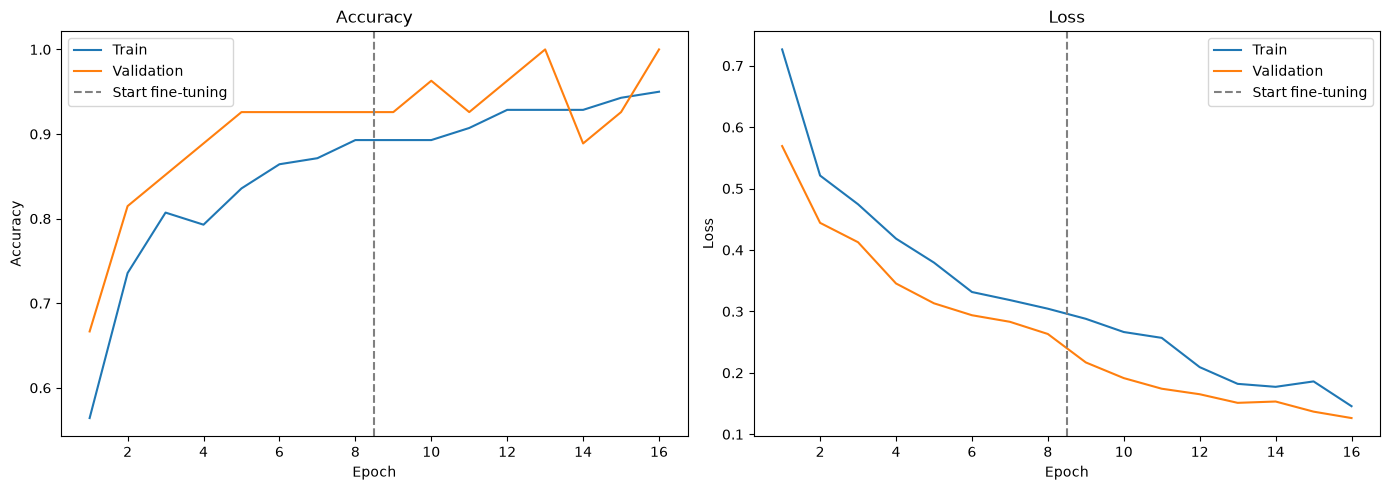

In [12]:
acc = history.history["accuracy"] + history_fine.history["accuracy"]
val_acc = history.history["val_accuracy"] + history_fine.history["val_accuracy"]
loss = history.history["loss"] + history_fine.history["loss"]
val_loss = history.history["val_loss"] + history_fine.history["val_loss"]

fine_tune_start = len(history.history["accuracy"])
epochs_range = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
ax1.plot(epochs_range, acc, label="Train")
ax1.plot(epochs_range, val_acc, label="Validation")
ax1.axvline(fine_tune_start + 0.5, color="gray", linestyle="--", label="Start fine-tuning")
ax1.set_title("Accuracy")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Accuracy")
ax1.legend()

ax2.plot(epochs_range, loss, label="Train")
ax2.plot(epochs_range, val_loss, label="Validation")
ax2.axvline(fine_tune_start + 0.5, color="gray", linestyle="--", label="Start fine-tuning")
ax2.set_title("Loss")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Loss")
ax2.legend()

plt.tight_layout()
plt.show()

## 10. Test the model on real thermal images

1. A confusion matrix + per-class report over the whole test set.
2. A visual grid of predictions (green = correct, red = wrong).

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


              precision    recall  f1-score   support

         dog       1.00      0.89      0.94         9
      person       0.90      1.00      0.95         9

    accuracy                           0.94        18
   macro avg       0.95      0.94      0.94        18
weighted avg       0.95      0.94      0.94        18



2026-07-08 19:18:41.112359: I tensorflow/core/framework/local_rendezvous.cc:404] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


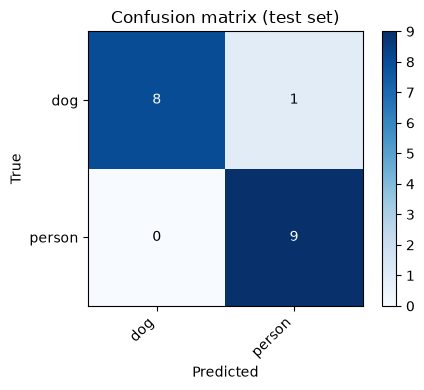

In [13]:
from sklearn.metrics import classification_report, confusion_matrix

# Single pass keeps images and labels aligned.
y_true, y_pred = [], []
for imgs, lbls in test_set:
    probs = model.predict(imgs, verbose=0)
    y_true.append(lbls.numpy())
    y_pred.append(np.argmax(probs, axis=1))

y_true = np.concatenate(y_true)
y_pred = np.concatenate(y_pred)

print(classification_report(y_true, y_pred, target_names=class_names))

cm = confusion_matrix(y_true, y_pred)
fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm, cmap="Blues")
ax.set_xticks(range(n_classes))
ax.set_yticks(range(n_classes))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix (test set)")
for i in range(n_classes):
    for j in range(n_classes):
        ax.text(j, i, cm[i, j], ha="center", va="center",
                color="white" if cm[i, j] > cm.max() / 2 else "black")
fig.colorbar(im)
plt.tight_layout()
plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step


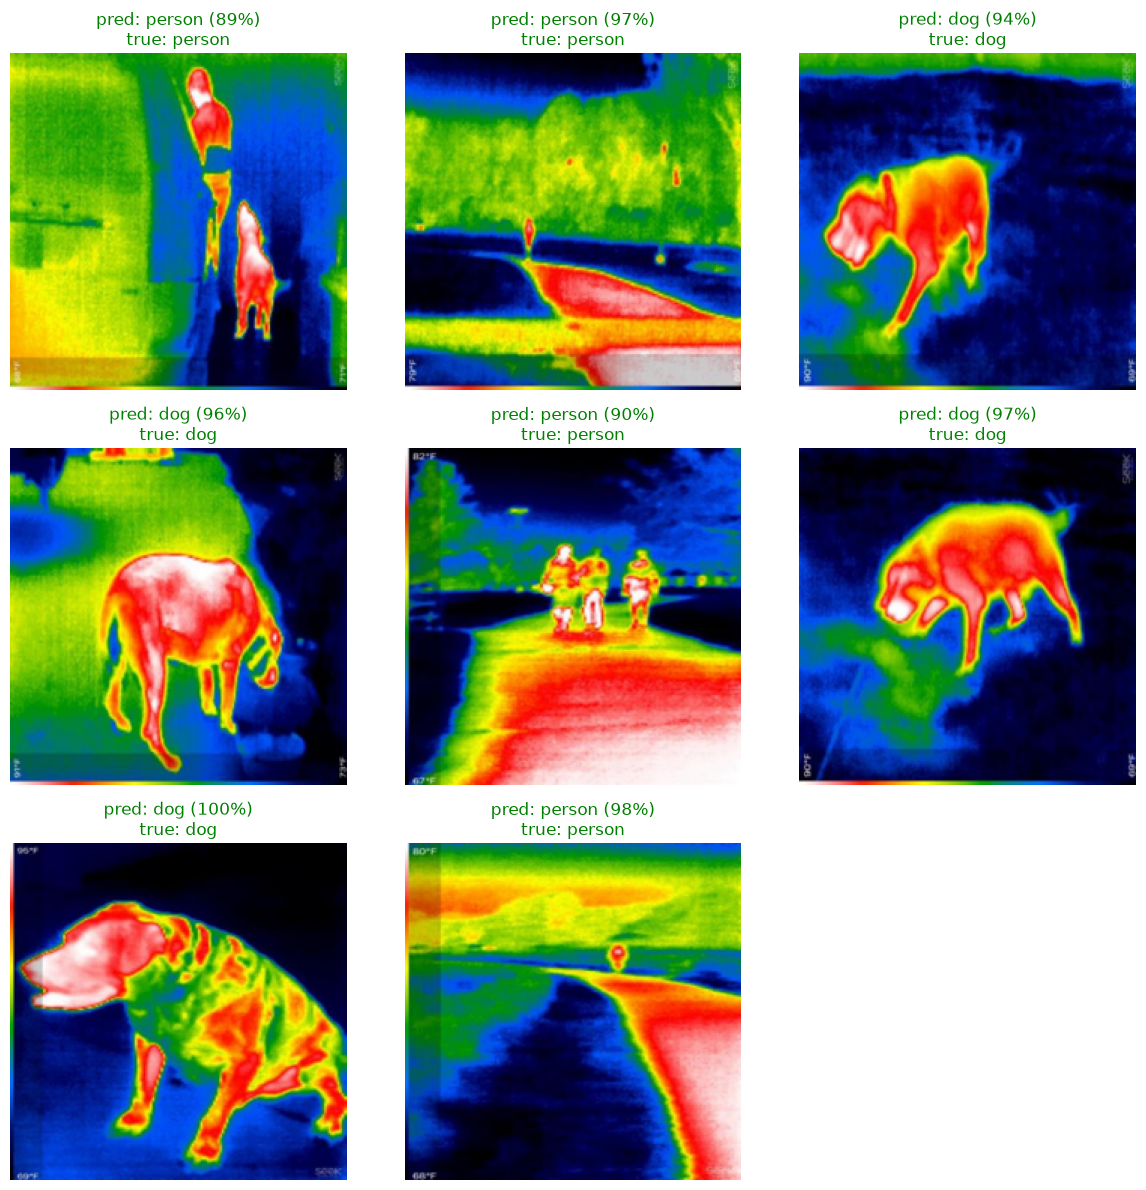

In [14]:
# Visualize predictions on one batch of test images
imgs, lbls = next(iter(test_set))
probs = model.predict(imgs)
preds = np.argmax(probs, axis=1)

n_show = min(9, imgs.shape[0])
plt.figure(figsize=(12, 12))
for i in range(n_show):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(imgs[i].numpy().astype("uint8"))
    true_name = class_names[int(lbls[i].numpy())]
    pred_name = class_names[preds[i]]
    confidence = probs[i][preds[i]]
    correct = pred_name == true_name
    ax.set_title(
        f"pred: {pred_name} ({confidence:.0%})\ntrue: {true_name}",
        color="green" if correct else "red",
    )
    plt.axis("off")
plt.tight_layout()
plt.show()

## 11. Key takeaways & exercises

### Key takeaways
- Features learned on ordinary photos (ImageNet) **transfer even to thermal images** —
  a modality the backbone never saw during pre-training.
- Transfer learning is the right tool for a **small, unusual dataset** like this one.
- The recipe is identical regardless of domain: **freeze → train head → fine-tune gently**.
- With few images, **augmentation and dropout** are your main defences against overfitting.

### Try it yourself 🛠️
1. **Class imbalance:** print the per-class counts — is one class rarer? Try
   `class_weight` in `model.fit` and see if recall on the rare class improves.
2. **Add EarlyStopping** (`keras.callbacks.EarlyStopping`) to stop when validation loss
   plateaus, and `ModelCheckpoint` to keep the best weights.
3. **Swap the backbone** to `MobileNetV2` — much smaller and faster. How much accuracy
   do you trade away?
4. **Bring your own thermal images:** drop images into `class_name/` folders and load them
   with `keras.utils.image_dataset_from_directory` instead — the rest of the notebook is unchanged.
5. **Grad-CAM:** visualize *where* the model looks in a thermal frame to make its decision.